# Task A: Data Audit & Quality

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the entire project
sns.set_theme(style="whitegrid")

# Load the Excel dataset from the current workspace directory
df = pd.read_excel('data.xlsx', sheet_name='E Comm')

print("Initial Data Audit.")
print(f"Total Number of Customers (Rows): {df.shape[0]}")
print(f"Total Number of Features (Columns): {df.shape[1]}\n")

# Check for Missing Values per column
missing_summary = df.isnull().sum()
print("Missing Values Detected:")
print(missing_summary[missing_summary > 0])
print("\n")

# Check target class balance (Churn column)
print("Target distribution (Churn):")
print(df['Churn'].value_counts(normalize=True) * 100)

Initial Data Audit.
Total Number of Customers (Rows): 5630
Total Number of Features (Columns): 20

Missing Values Detected:
CustomerID                       2
Tenure                         264
WarehouseToHome                251
Gender                           2
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


Target distribution (Churn):
Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64


In [20]:
# Check ranges for Tenure and WarehouseToHome to spot inconsistencies
print("Checking ranges for anomalies:")
print(df[['Tenure', 'WarehouseToHome']].describe().loc[['min', 'max']])
print("\n")

# Count specific anomalies if they exist 
extreme_warehouse = df[df['WarehouseToHome'] > 100].shape[0]
extreme_tenure = df[df['Tenure'] > 100].shape[0]

print(f"Customers with WarehouseToHome > 100 km: {extreme_warehouse}")
print(f"Customers with Tenure > 100 months: {extreme_tenure}")

Checking ranges for anomalies:
     Tenure  WarehouseToHome
min     0.0              5.0
max    61.0            127.0


Customers with WarehouseToHome > 100 km: 2
Customers with Tenure > 100 months: 0


In [21]:
# Handle the 2 extreme distance outliers in WarehouseToHome
df = df[df['WarehouseToHome'] <= 100]

# Identify Categorical Columns for Encoding
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

# Perform One-Hot Encoding to convert text fields into numeric flags (0 or 1)
# drop_first=True reduces multi-collinearity, which is crucial for Logistic Regression
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Final Data Integrity Check before Modeling
print("Prepared Dataset for ML:")
print(f"Final Rows count: {df_encoded.shape[0]}")
print(f"Final Columns count (after encoding): {df_encoded.shape[1]}")
print(f"Any remaining missing values? {df_encoded.isnull().sum().sum()}")

Prepared Dataset for ML:
Final Rows count: 5377
Final Columns count (after encoding): 33
Any remaining missing values? 1607


# Task B: Exploratory Data Analysis (EDA) 

Correlation matrix with Churn:
Churn                1.000000
Complain             0.238605
SatisfactionScore    0.103177
Name: Churn, dtype: float64


Churn rate by complaints (%):
Churn             0          1
Complain                      
0         89.427313  10.572687
1         69.960474  30.039526




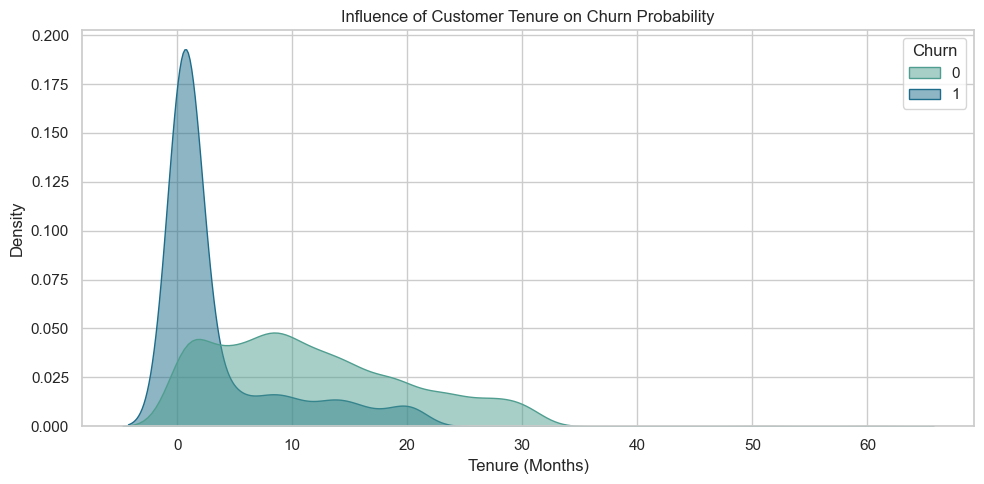

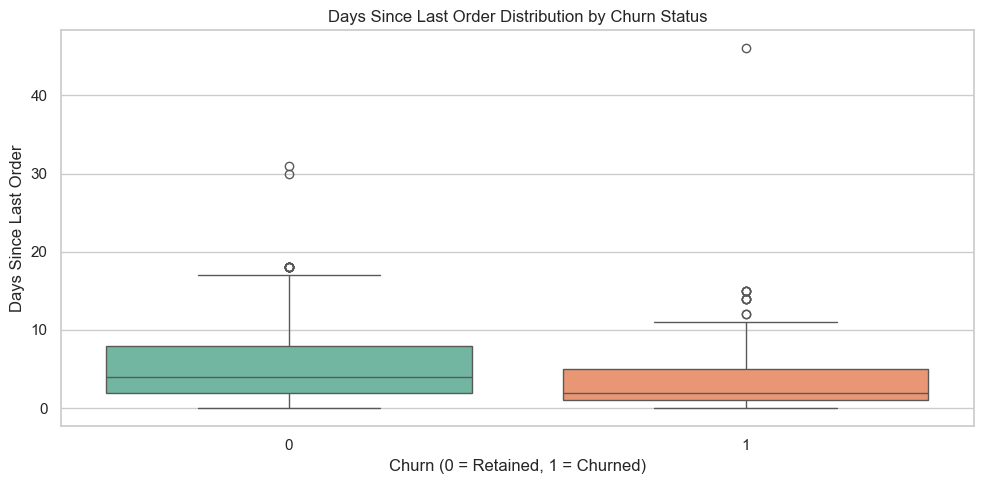

In [22]:
# Analyzing correlation between Complain, SatisfactionScore, and Churn
churn_corr = df_encoded[['Complain', 'SatisfactionScore', 'Churn']].corr()
print("Correlation matrix with Churn:")
print(churn_corr['Churn'].sort_values(ascending=False))
print("\n")

# Impact of Complaints on Churn
complain_churn = pd.crosstab(df['Complain'], df['Churn'], normalize='index') * 100
print("Churn rate by complaints (%):")
print(complain_churn)
print("\n")

# Visualizing Churn Probability by Tenure
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Tenure', hue='Churn', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Influence of Customer Tenure on Churn Probability')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

# Visualizing Churn Probability by Days Since Last Order 
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Churn', y='DaySinceLastOrder', hue='Churn', palette='Set2', legend=False)
plt.title('Days Since Last Order Distribution by Churn Status')
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Days Since Last Order')
plt.tight_layout()
plt.show()

# Task C: Modeling & Evaluation

In [24]:
# TASK A & C: ROBUST DATA PIPELINE & MODEL TRAINING
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score

# Step 1: Reload a fresh copy of the dataset to avoid memory state conflicts
df_clean = pd.read_excel('data.xlsx', sheet_name='E Comm')

# Step 2: Handle Missing Values on the fresh dataframe
df_clean = df_clean.dropna(subset=['CustomerID'])

numerical_missing_cols = [
    'Tenure', 'WarehouseToHome', 'HourSpendOnApp', 
    'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder'
]

for col in numerical_missing_cols:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)

df_clean['Gender'] = df_clean['Gender'].fillna(df_clean['Gender'].mode()[0])

# Step 3: Filter extreme distance outliers (WarehouseToHome > 100)
df_clean = df_clean[df_clean['WarehouseToHome'] <= 100]

# Step 4: Perform One-Hot Encoding on the fully cleaned dataframe
categorical_cols = ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']
df_final = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

# Step 5: Separate Features (X) and Target (y)
X = df_final.drop(columns=['CustomerID', 'Churn'])
y = df_final['Churn']

# Step 6: Split into Train and Test sets (80% Train, 20% Test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split completed.")
print(f"Verified Remaining NaNs in Train Set: {X_train.isna().sum().sum()}")
print(f"Training set size: {X_train.shape[0]} customers")
print(f"Testing set size: {X_test.shape[0]} customers\n")

# Step 7: Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Step 8: Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)


Data split completed.
Verified Remaining NaNs in Train Set: 0
Training set size: 4500 customers
Testing set size: 1126 customers



c:\Users\Martina\ai4cm\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression performance:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       936
           1       0.83      0.53      0.64       190

    accuracy                           0.90      1126
   macro avg       0.87      0.75      0.79      1126
weighted avg       0.90      0.90      0.89      1126

Random Forest performance:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       936
           1       0.98      0.90      0.94       190

    accuracy                           0.98      1126
   macro avg       0.98      0.95      0.96      1126
weighted avg       0.98      0.98      0.98      1126



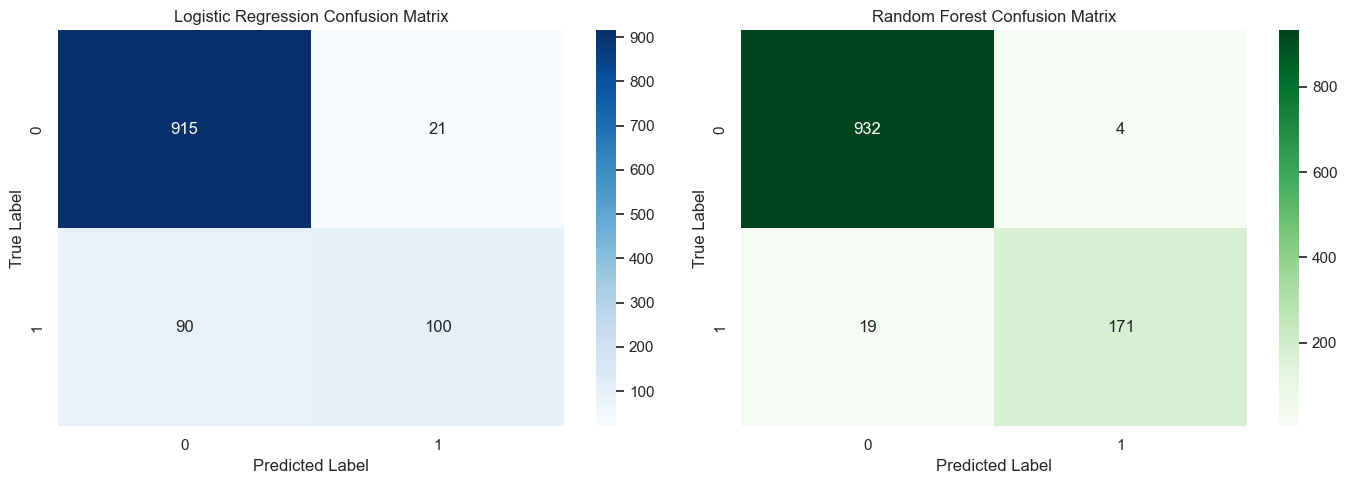

In [25]:
# Print Classification Report for Logistic Regression
print("Logistic Regression performance:")
print(classification_report(y_test, lr_preds))

# Print Classification Report for Random Forest
print("Random Forest performance:")
print(classification_report(y_test, rf_preds))

# Plotting Confusion Matrices side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Heatmap
sns.heatmap(confusion_matrix(y_test, lr_preds), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Logistic Regression Confusion Matrix')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

# Random Forest Heatmap
sns.heatmap(confusion_matrix(y_test, rf_preds), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Random Forest Confusion Matrix')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

In [26]:
print("TASK C: BUSINESS EVALUATION OF THE PROPENSITY MODEL")
evaluation_text = """
Model Comparison & Metric Rationale:
- Champion Model: Random Forest drastically outperforms Logistic Regression, achieving an overall Accuracy of 98% and an F1-Score for Churners of 0.94 (vs 0.64).
- The Crucial Metric (Recall): For Churn (Class 1), Random Forest achieved 90% Recall compared to just 53% for Logistic Regression.
- Business Justification: In customer retention, the cost of a False Negative (missing a churner) is vastly higher than a False Positive (incentivizing a loyal customer). Missing a churner means losing a customer lifetime value and incurring high re-acquisition costs. Misidentifying a loyal customer only results in the minor marginal cost of a retention discount. Therefore, maximizing Recall is the optimal financial decision.
"""
print(evaluation_text)

# Extracting the feature importances from our Champion Model (Random Forest)
importances = rf_model.feature_importances_
feature_names = X.columns
rf_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("TASK D: TOP 3 RISK DRIVERS IDENTIFIED BY AI")
for rank, (feature, importance) in enumerate(rf_importances.head(3).items(), 1):
    print(f" Risk Driver {rank}: {feature} (Importance Score: {importance:.4f})")

print("\n STRATEGIC MARKETING ACTION PLAN FOR THE CEO")
marketing_plan = """
1. Retention Campaign on Complaints: Implement a 24-hour SLA response rule for any active customer raising a 'Complain'. Offer immediate loyalty cashback points to reverse the negative friction.
2. New Joiner Onboarding (Low Tenure): Deploy a structured drip email automation sequence for users in their first 3 months (the highest density churn window discovered in EDA), focusing on product discovery and satisfaction pulse checks.
3. Proactive Win-Back: Target users identified by the Random Forest model with a high propensity score (>80%) but who haven't ordered recently, using automated time-limited coupons matching their 'PreferedOrderCat'.
"""
print(marketing_plan)

TASK C: BUSINESS EVALUATION OF THE PROPENSITY MODEL

Model Comparison & Metric Rationale:
- Champion Model: Random Forest drastically outperforms Logistic Regression, achieving an overall Accuracy of 98% and an F1-Score for Churners of 0.94 (vs 0.64).
- The Crucial Metric (Recall): For Churn (Class 1), Random Forest achieved 90% Recall compared to just 53% for Logistic Regression.
- Business Justification: In customer retention, the cost of a False Negative (missing a churner) is vastly higher than a False Positive (incentivizing a loyal customer). Missing a churner means losing a customer lifetime value and incurring high re-acquisition costs. Misidentifying a loyal customer only results in the minor marginal cost of a retention discount. Therefore, maximizing Recall is the optimal financial decision.

TASK D: TOP 3 RISK DRIVERS IDENTIFIED BY AI
 Risk Driver 1: Tenure (Importance Score: 0.2073)
 Risk Driver 2: CashbackAmount (Importance Score: 0.1017)
 Risk Driver 3: WarehouseToHome (